# 水吸収バンド(1450 / 1940 nm)周辺スペクトルの可視化

水の O–H 倍音吸収帯である **1450 nm**(第1倍音)と **1940 nm**(結合音)を中心に、
各バンド ±50 nm(幅 ~100 nm)の領域を切り出して可視化する。

- **前処理**: SNV / SNV+SG1(1次微分) / SNV+SG2(2次微分)
- **train**: 含水率(MC)で連続カラー着色 → 含水率と吸収の関係を見る
- **test**: 含水率ラベルが無いため**樹種**で離散着色し、train の上に重ねる

> 出典: 水の近赤外吸収帯 1450 nm(O–H 第1倍音)・1940 nm(O–H 伸縮+変角の結合音)。
> Workman & Weyer, *Practical Guide to Interpretive Near-Infrared Spectroscopy* (2007).
> 前処理(SNV)実装は本リポジトリ `nir_features.snv`。

In [106]:
import os, sys
if not os.path.exists('data/train_clean.csv') and os.path.exists('../data/train_clean.csv'):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter

from nir_features import snv

mpl.rcParams['font.family'] = 'Hiragino Sans'   # 日本語(樹種名)表示用
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

In [107]:
# ---- データ読み込み(Shift-JIS, メタ列 + 波数[cm^-1]降順) ----
META_TR = ['sample number', 'species number', '樹種', '含水率']
META_TE = ['sample number', 'species number', '樹種']

train = pd.read_csv('data/train_clean.csv', encoding='shift-jis')
test  = pd.read_csv('data/test.csv',  encoding='shift-jis')

wn = train.columns[len(META_TR):].astype(float).values   # 波数 cm^-1
nm = 1e7 / wn                                             # 波長 nm に変換
order = np.argsort(nm)                                    # nm 昇順に並べ替え
nm = nm[order]

Xtr = train.iloc[:, len(META_TR):].values[:, order]
Xte = test.iloc[:,  len(META_TE):].values[:, order]
ytr = train['含水率'].values
sp_te = test['樹種'].values

print('train', Xtr.shape, ' test', Xte.shape)
print('nm range: %.1f – %.1f nm' % (nm.min(), nm.max()))
print('含水率 range: %.1f – %.1f %%' % (ytr.min(), ytr.max()))
print('test 樹種:', sorted(pd.unique(sp_te)))

train (1270, 1555)  test (550, 1555)
nm range: 1000.6 – 2500.1 nm
含水率 range: 0.8 – 298.6 %
test 樹種: ['クスノキ', 'ケヤキ', 'スギ', 'タモ', 'チーク', 'ヤマザクラ']


In [108]:
# ---- 前処理: SNV / SNV+SG1 / SNV+SG2 ----
# SG は nm 昇順・等間隔近似で適用(窓は奇数点)。微分は散乱・ベースライン補正に有効。
SG_WIN, SG_POLY = 11, 2

def preprocess(X, kind):
    Xs = snv(X)
    if kind == 'SNV':
        return Xs
    deriv = 1 if kind == 'SNV+SG1' else 2
    return savgol_filter(Xs, SG_WIN, SG_POLY, deriv=deriv, axis=1)

KINDS = ['SNV', 'SNV+SG1', 'SNV+SG2']

## 可視化バンドの設定(ここを編集)

`BANDS` を編集すれば、以降の **すべての可視化セル**(重ね描き / train のみ / test 1樹種ずつ)が
その波長帯で描画される。`(中心nm, 片側幅nm)` のタプルを並べるだけ。
`PP_KIND` は test を1樹種ずつ描くセルで使う前処理。

In [109]:
# ====== ここを編集して可視化バンドを変更(全可視化セル共通) ======
# 各バンドは (下限nm, 上限nm) の境界で指定する。
BANDS = [
    (1000, 1300),
    (1430, 1470),   # 水 O-H 第1倍音(~1450)
    (1910, 1950),   # 水 O-H 結合音(~1940)
    (2000, 2100),
    (2380, 2500)
    # (1150, 1250), # 例: 他の帯を足したい場合はコメントを外す
]
PP_KIND = 'SNV'        # test 1樹種ずつ可視化で使う前処理: 'SNV' / 'SNV+SG1' / 'SNV+SG2'
# ===============================================================
assert PP_KIND in KINDS, PP_KIND

In [110]:
# ---- 可視化関数: 1バンド × 1前処理 ----
# train を含水率で連続着色、test を樹種で離散着色して重ねる。
def plot_band(ax, kind, lo, hi, n_train=400, rng=None):
    rng = rng or np.random.default_rng(0)
    m = (nm >= lo) & (nm <= hi)
    w = nm[m]

    Ytr = preprocess(Xtr, kind)[:, m]
    Yte = preprocess(Xte, kind)[:, m]

    # train: 含水率で着色(本数が多いのでサブサンプル)
    idx = rng.choice(len(Ytr), min(n_train, len(Ytr)), replace=False)
    norm = mpl.colors.Normalize(vmin=ytr.min(), vmax=np.percentile(ytr, 99))
    cmap = plt.cm.viridis
    for i in idx:
        ax.plot(w, Ytr[i], color=cmap(norm(ytr[i])), lw=0.4, alpha=0.45)

    # test: 樹種で着色して重ねる
    species = sorted(pd.unique(sp_te))
    tcols = plt.cm.tab10(np.linspace(0, 1, len(species)))
    cmap_te = dict(zip(species, tcols))
    for s in species:
        for j in np.where(sp_te == s)[0]:
            ax.plot(w, Yte[j], color=cmap_te[s], lw=0.7, alpha=0.8)

    ax.set_title(f'{kind}  |  {lo}-{hi} nm')
    ax.set_xlabel('波長 [nm]')
    ax.set_ylabel('吸光度' if kind == 'SNV' else f'{kind.split("+")[-1]} 応答')
    return norm, cmap, cmap_te

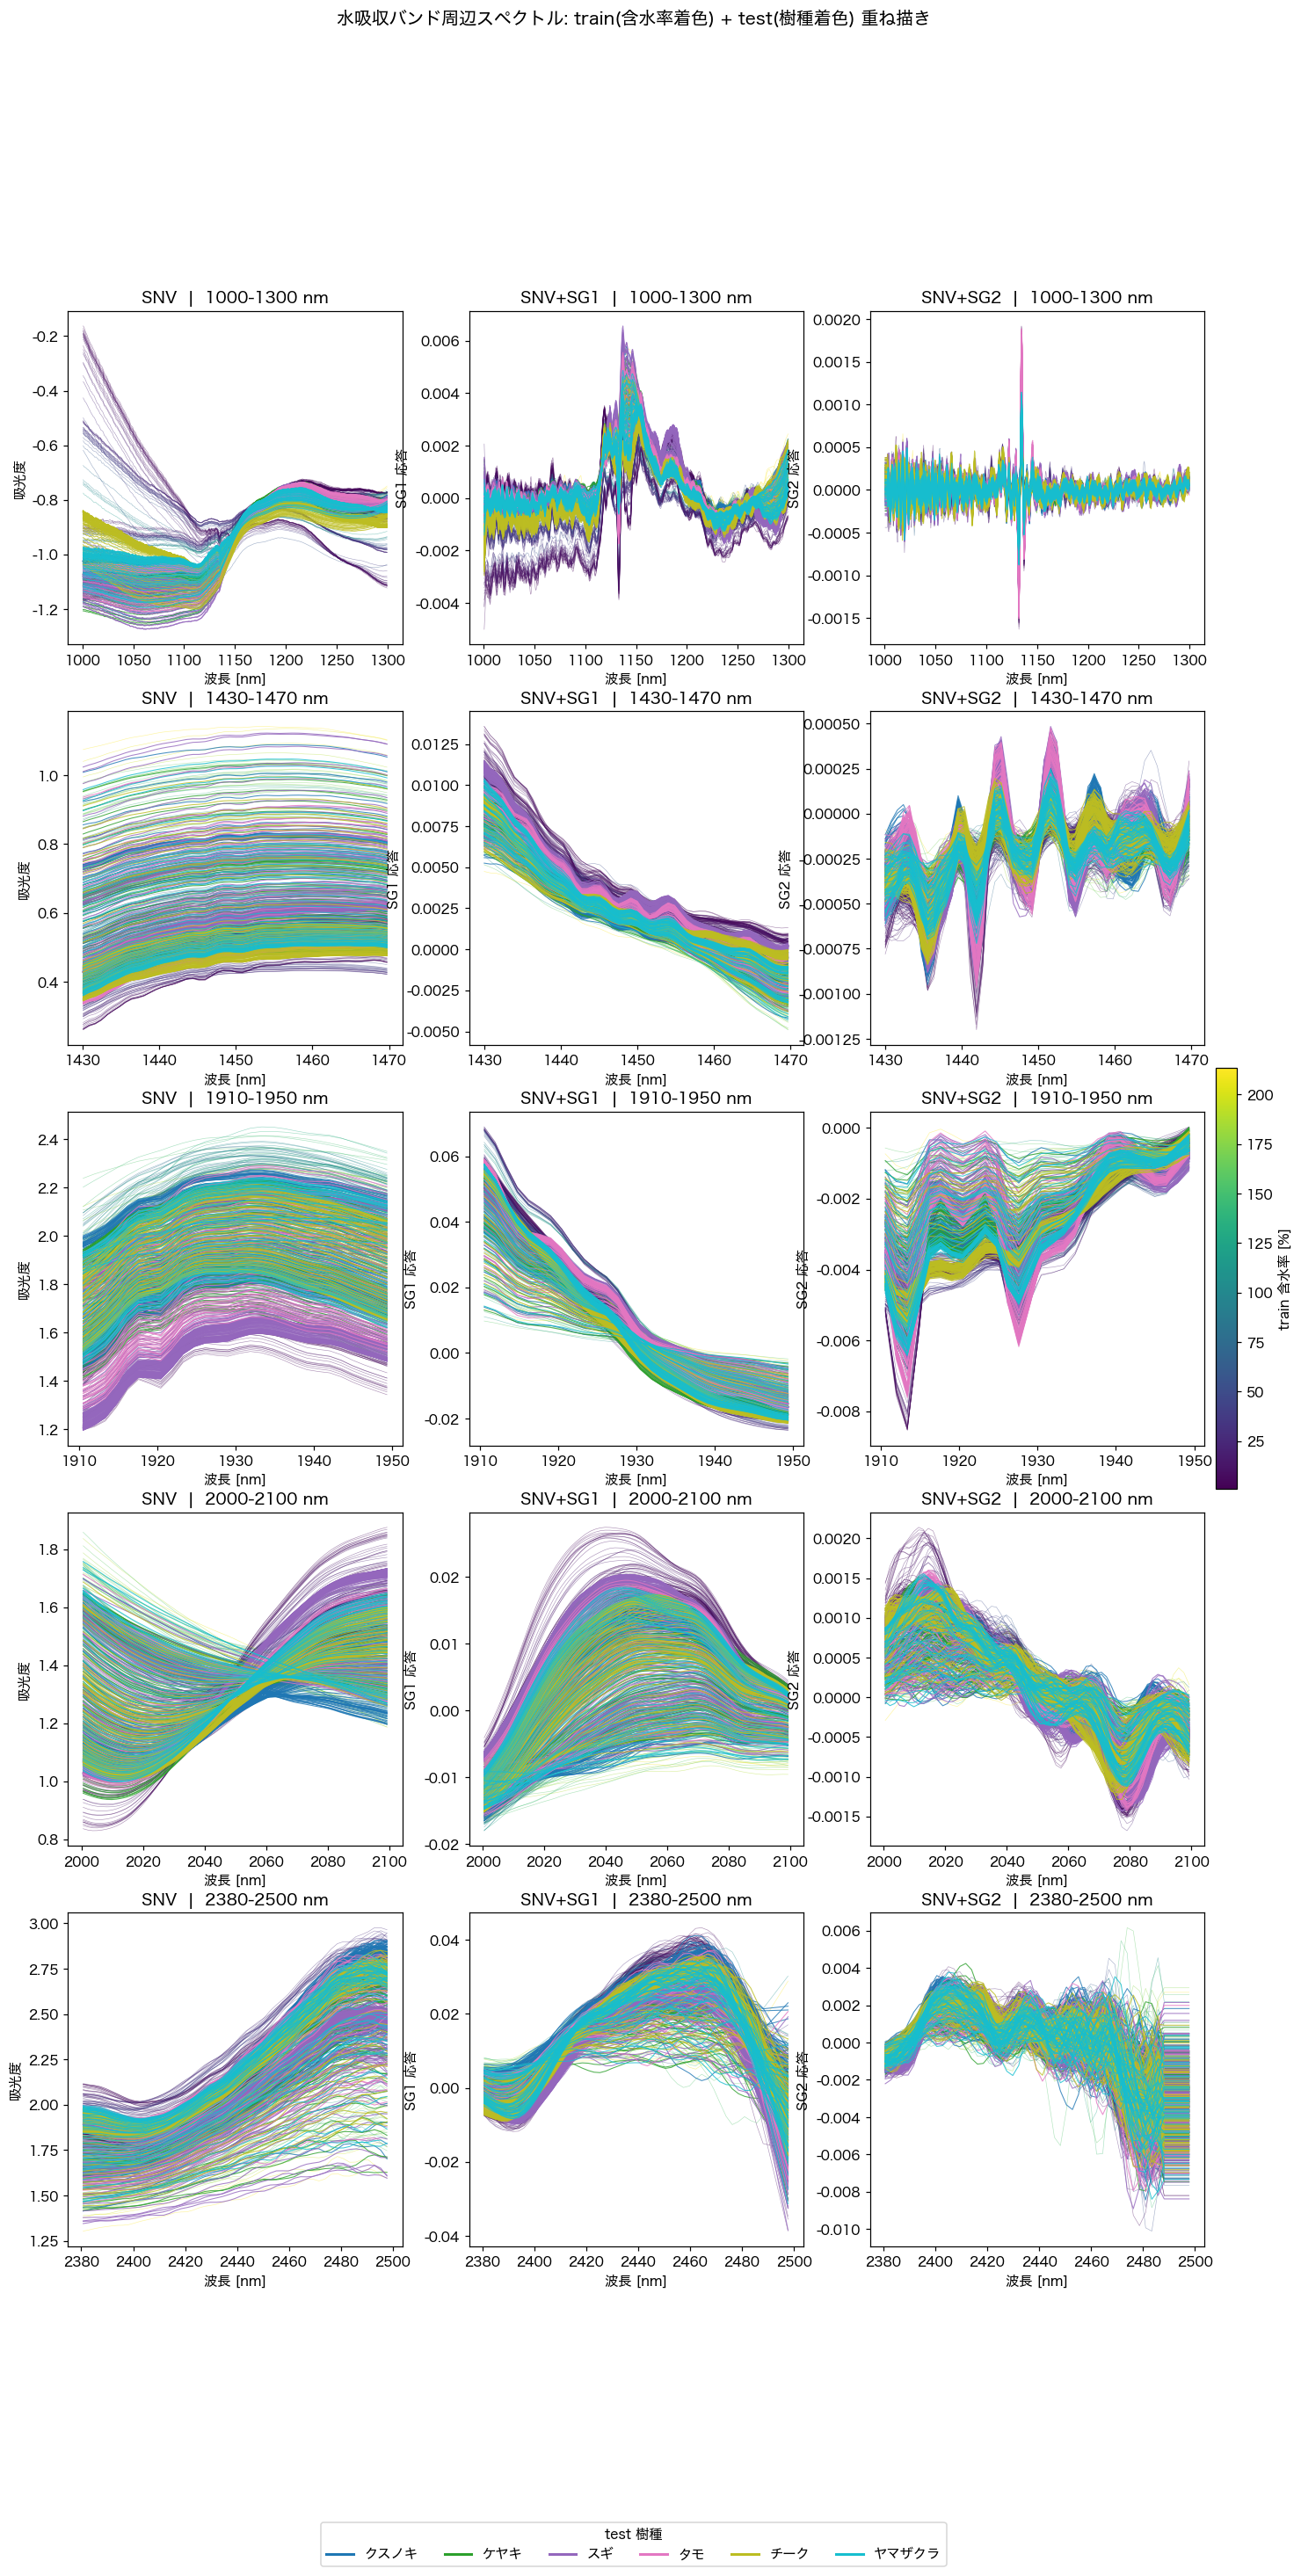

In [111]:
# ---- 描画: 行=BANDS, 列=前処理(SNV/SG1/SG2) ----
fig, axes = plt.subplots(len(BANDS), len(KINDS), squeeze=False,
                         figsize=(5.2*len(KINDS), 5.2*len(BANDS)))

for r, (lo, hi) in enumerate(BANDS):
    for c, kind in enumerate(KINDS):
        norm, cmap, cmap_te = plot_band(axes[r, c], kind, lo, hi)

# train の含水率カラーバー
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=axes, fraction=0.018, pad=0.01)
cb.set_label('train 含水率 [%]')

# test 樹種の凡例
handles = [Line2D([0],[0], color=cmap_te[s], lw=2, label=s) for s in cmap_te]
fig.legend(handles=handles, title='test 樹種', loc='lower center',
           ncol=len(handles), bbox_to_anchor=(0.5, -0.02))
fig.suptitle('水吸収バンド周辺スペクトル: train(含水率着色) + test(樹種着色) 重ね描き',
             y=1.0, fontsize=13)
plt.show()

## 読み取りのポイント

- **train(viridis)**: 含水率が高いほど水バンド(1450/1940 nm)の吸収が深くなるなら、
  含水率と色のグラデーションがバンド中心で揃って見えるはず。
- **test(tab10 樹種)**: 含水率は不明だが、test 樹種の線が train の含水率グラデーションの
  どの帯に重なるかで、おおよその含水率水準・外挿域の妥当性を視覚的に確認できる。
- SG1/SG2 はベースライン差を除いてバンド形状(変曲点・ピーク位置)を強調する。
  test の線が train の分布内に収まっていれば、水バンド特徴での外挿が利きやすい。

> 関連: 強度特徴パイプラインは `nir_features.SNVEPOStrengthFeatures`(水バンド B2:1375-1470, B4:1985-2041 を使用)。

## train のみ(含水率着色)

重ね描きを外し、**train スペクトルだけ**を含水率で着色して水バンド周辺を見る。
含水率と吸収深さの単調な関係を確認しやすい。

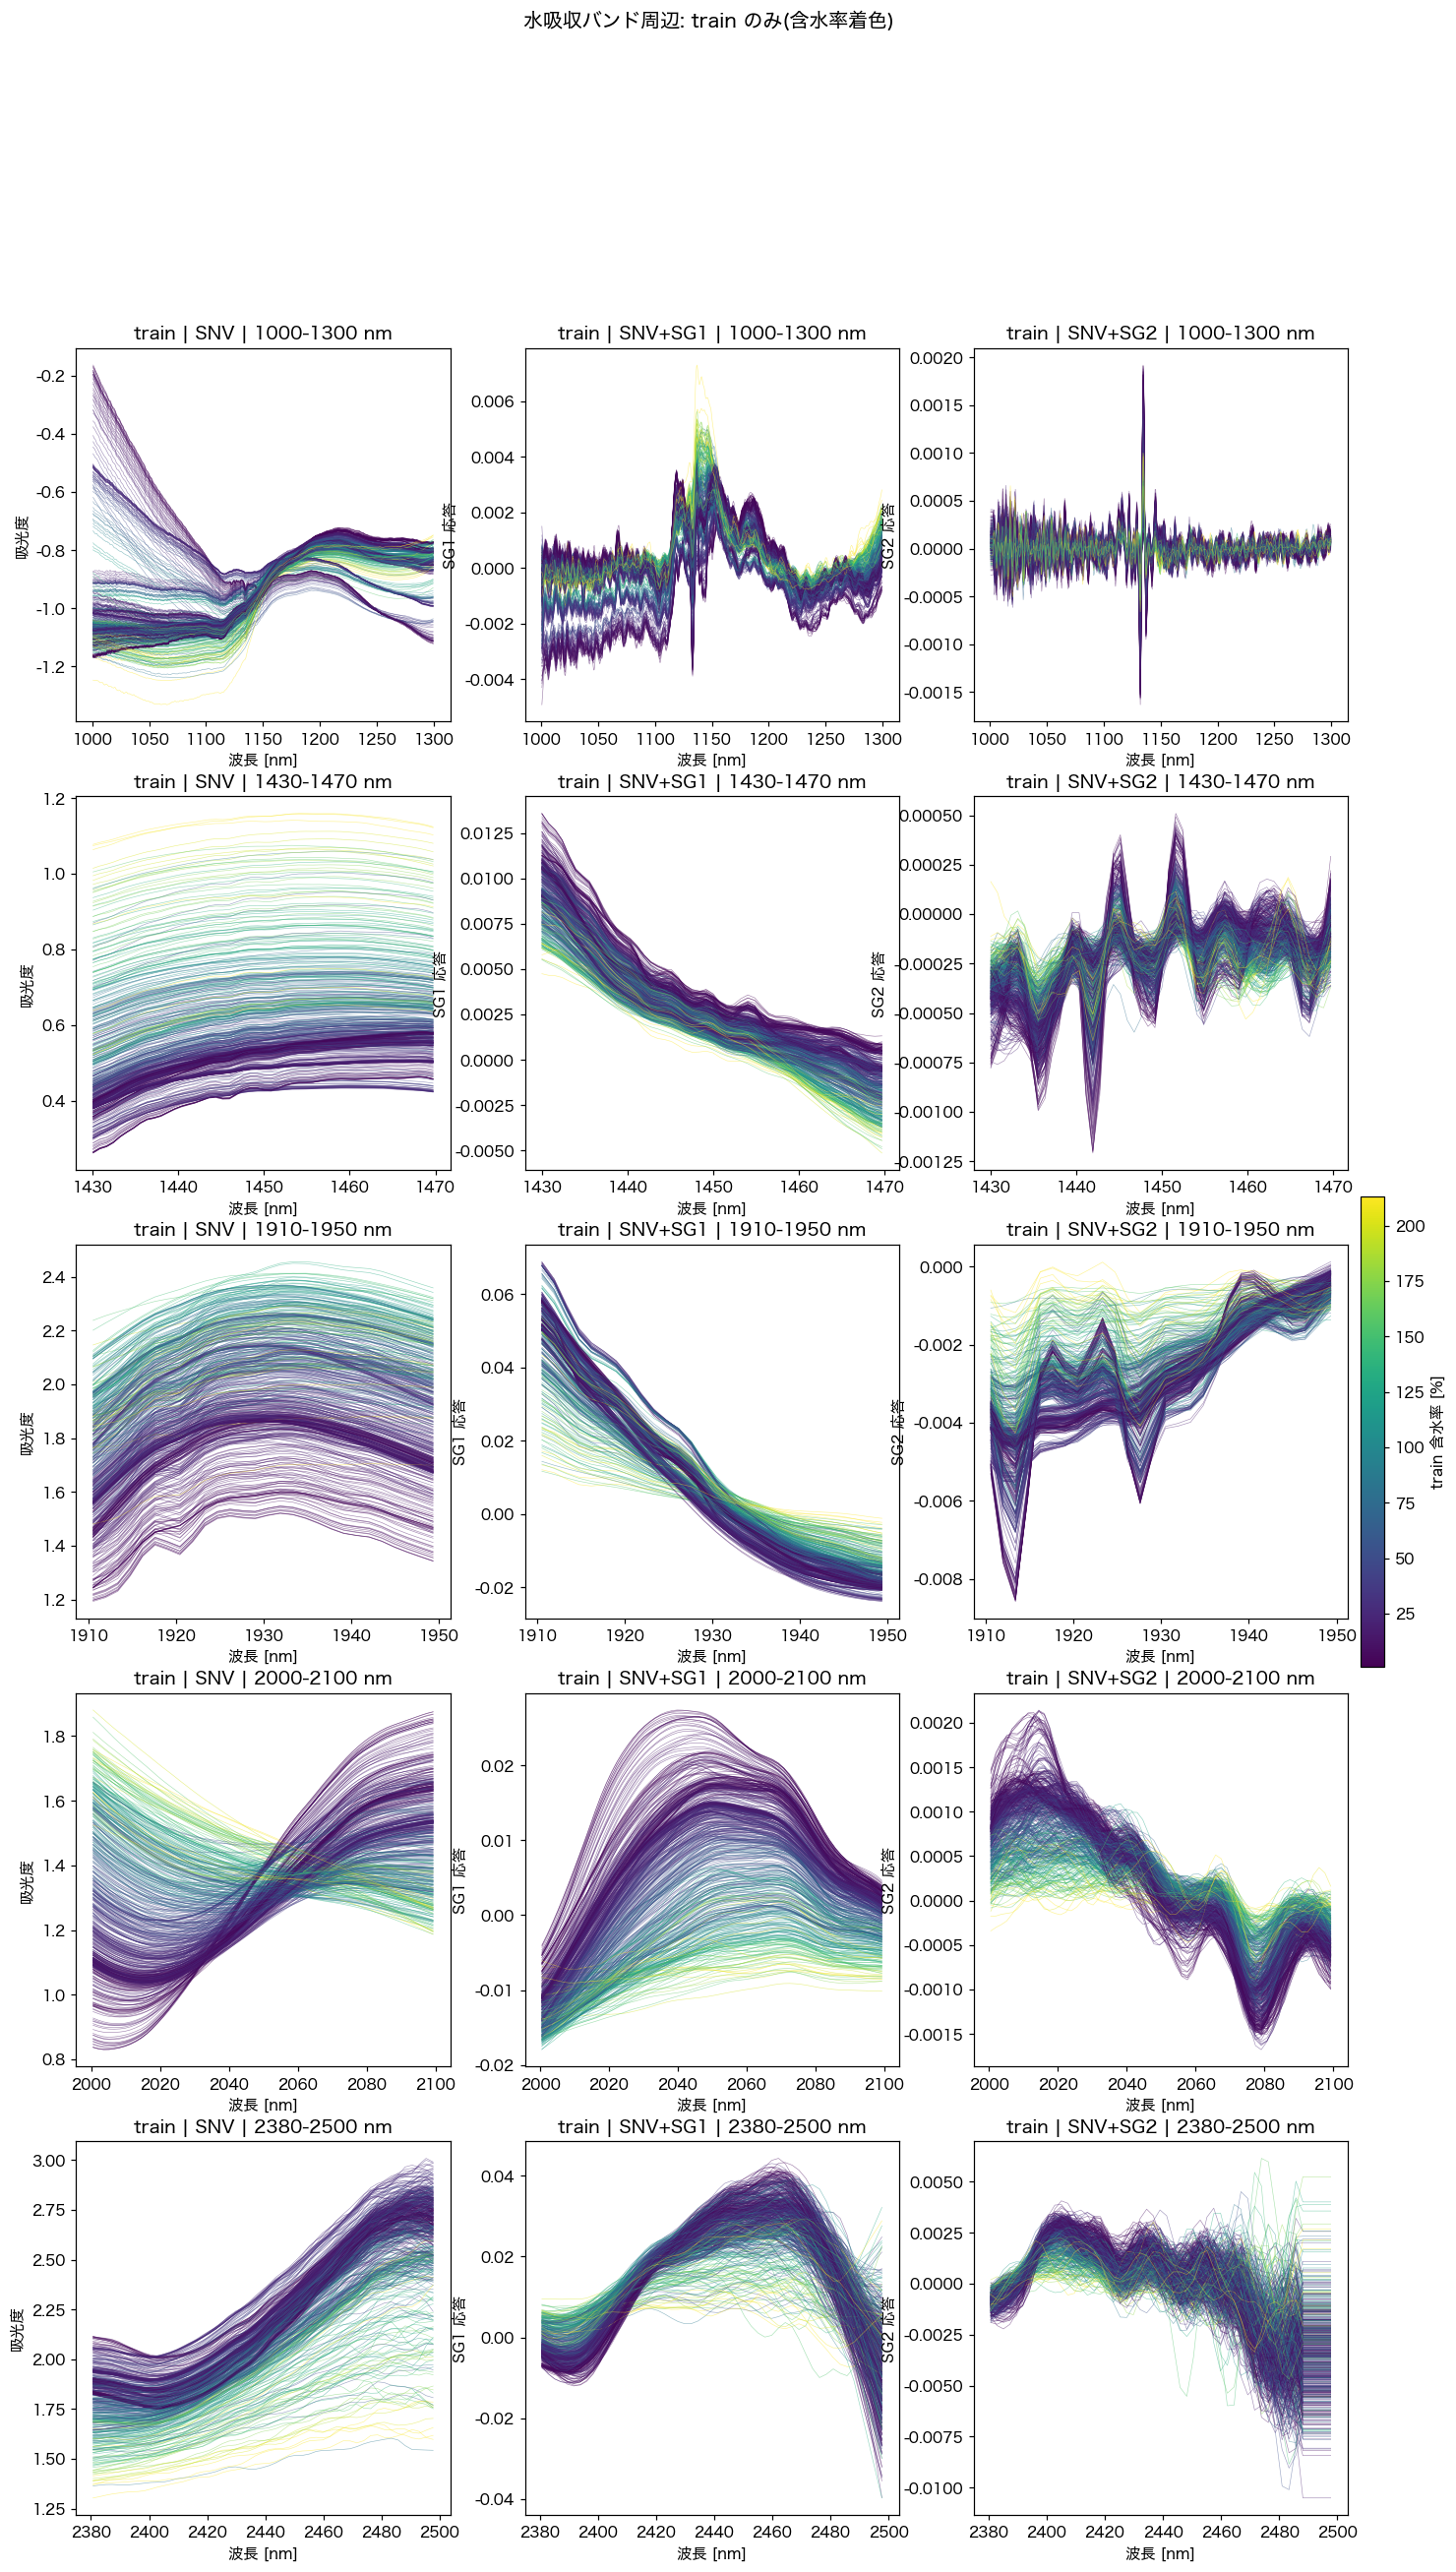

In [112]:
# ---- train のみ: 含水率で着色 ----
def plot_band_train(ax, kind, lo, hi, n_train=600, rng=None):
    rng = rng or np.random.default_rng(0)
    m = (nm >= lo) & (nm <= hi)
    w = nm[m]
    Y = preprocess(Xtr, kind)[:, m]
    idx = rng.choice(len(Y), min(n_train, len(Y)), replace=False)
    norm = mpl.colors.Normalize(vmin=ytr.min(), vmax=np.percentile(ytr, 99))
    cmap = plt.cm.viridis
    for i in idx:
        ax.plot(w, Y[i], color=cmap(norm(ytr[i])), lw=0.4, alpha=0.5)
    ax.set_title(f'train | {kind} | {lo}-{hi} nm')
    ax.set_xlabel('波長 [nm]'); ax.set_ylabel('吸光度' if kind=='SNV' else f'{kind.split("+")[-1]} 応答')
    return norm, cmap

fig, axes = plt.subplots(len(BANDS), len(KINDS), squeeze=False,
                         figsize=(5.2*len(KINDS), 5.2*len(BANDS)))
for r, (lo, hi) in enumerate(BANDS):
    for c, kind in enumerate(KINDS):
        norm, cmap = plot_band_train(axes[r, c], kind, lo, hi)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=axes, fraction=0.018, pad=0.01).set_label('train 含水率 [%]')
fig.suptitle('水吸収バンド周辺: train のみ(含水率着色)', y=1.0, fontsize=13)
plt.show()

### test を1樹種ずつ表示(各バンド)

行=test 樹種、列=バンド。各パネルにその樹種の test スペクトルのみを描く。
比較用に train 全体の範囲を薄いグレー帯で重ねる(含水率不明なので分布参照のみ)。

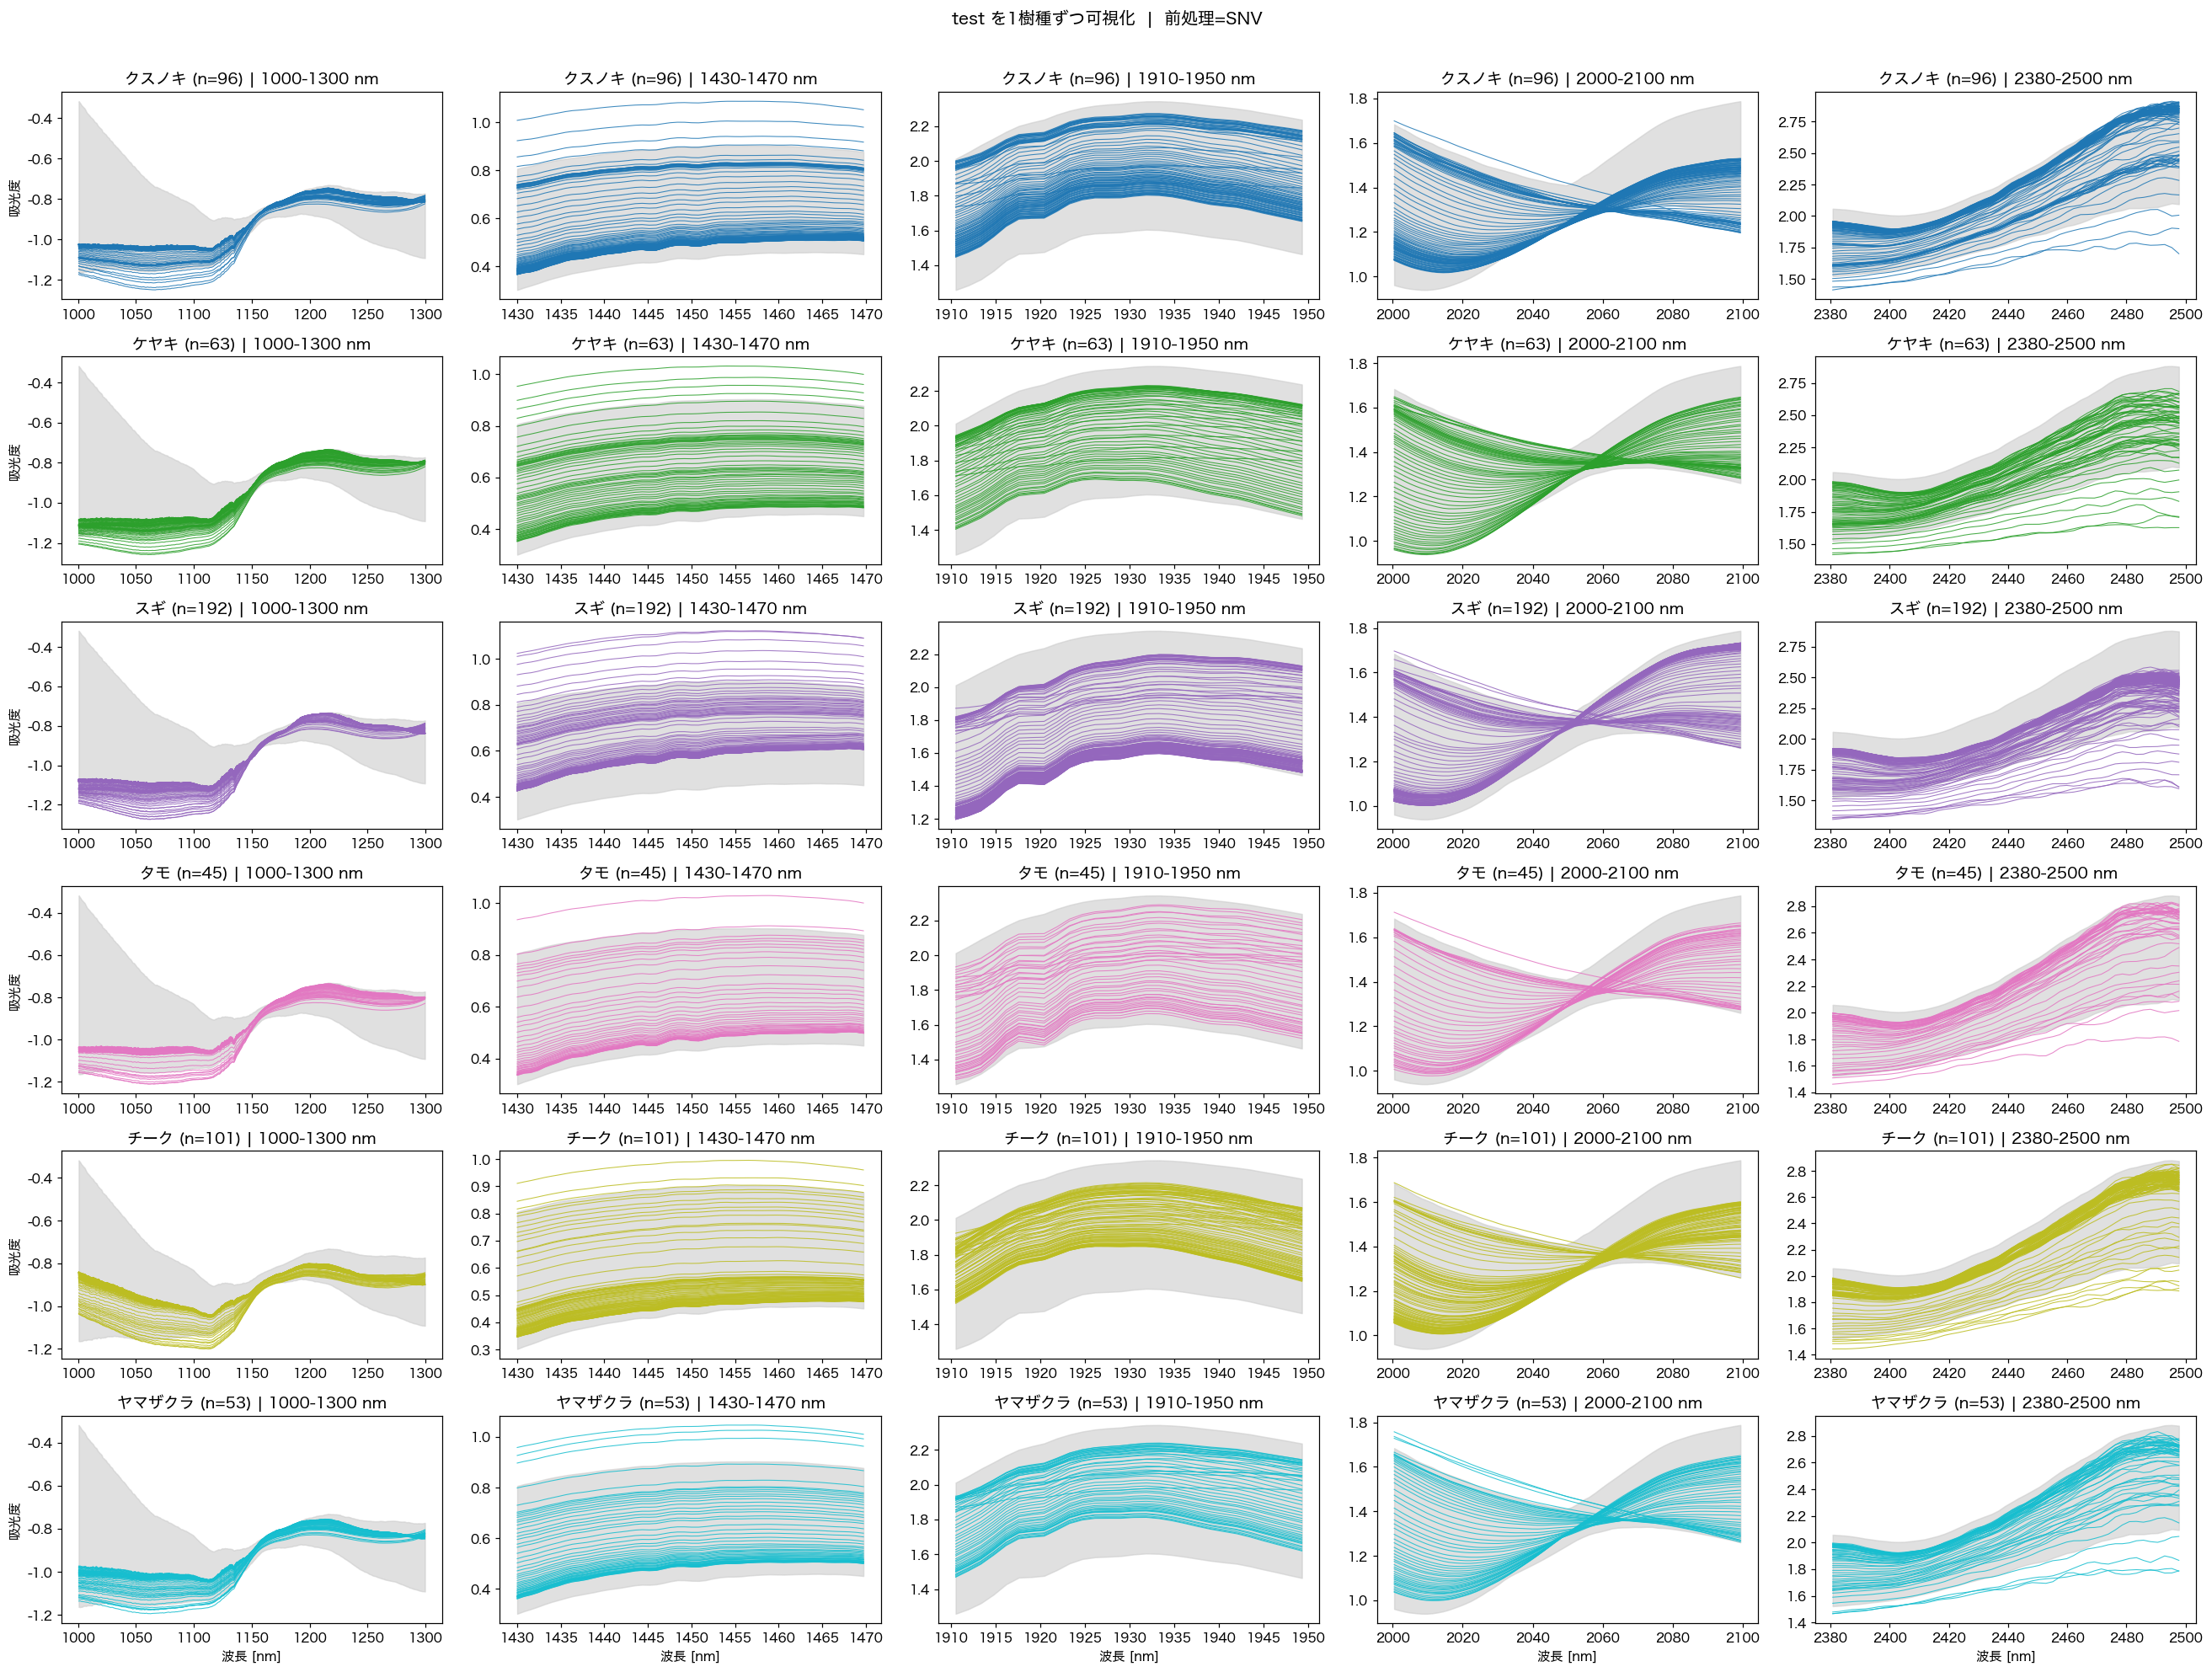

In [113]:
# ---- test を1樹種ずつ: 行=樹種, 列=BANDS ----
def _band_mask(lo, hi):
    m = (nm >= lo) & (nm <= hi)
    return m, nm[m]

species = sorted(pd.unique(sp_te))
Yte_pp = preprocess(Xte, PP_KIND)
Ytr_pp = preprocess(Xtr, PP_KIND)
tcols = dict(zip(species, plt.cm.tab10(np.linspace(0, 1, len(species)))))

fig, axes = plt.subplots(len(species), len(BANDS),
                         figsize=(4.8*len(BANDS), 3.0*len(species)), squeeze=False)
for r, s in enumerate(species):
    rows = np.where(sp_te == s)[0]
    for c, (lo, hi) in enumerate(BANDS):
        ax = axes[r, c]
        m, w = _band_mask(lo, hi)
        # train 範囲(参照): 5–95 パーセンタイル帯
        p_lo, p_hi = np.percentile(Ytr_pp[:, m], [5, 95], axis=0)
        ax.fill_between(w, p_lo, p_hi, color='0.8', alpha=0.6, label='train 5–95%' if r==0 and c==0 else None)
        for j in rows:
            ax.plot(w, Yte_pp[j][m], color=tcols[s], lw=0.7, alpha=0.85)
        ax.set_title(f'{s} (n={len(rows)}) | {lo}-{hi} nm')
        if r == len(species)-1: ax.set_xlabel('波長 [nm]')
        if c == 0: ax.set_ylabel('吸光度' if PP_KIND=='SNV' else f'{PP_KIND.split("+")[-1]} 応答')

fig.suptitle(f'test を1樹種ずつ可視化  |  前処理={PP_KIND}', y=1.0, fontsize=13)
fig.tight_layout(rect=[0,0,1,0.99])
plt.show()